In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from PIL import Image
from tqdm.notebook import tqdm
from skimage.transform import resize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
import torchvision.models as models
from exceptions.exceptions import InvalidBackboneError
class ResNetSimCLR(nn.Module):

    def __init__(self, base_model, out_dim):
        super(ResNetSimCLR, self).__init__()
        #self.resnet_dict = {"resnet18": models.resnet18(pretrained=True, num_classes=out_dim),
        #                    "resnet50": models.resnet50(pretrained=False, num_classes=out_dim)}
        model = models.resnet18(pretrained=False)
        num_feat = model.fc.in_features
        model.fc = nn.Linear(num_feat,out_dim)
        self.resnet_dict = {"resnet18": model}
        self.backbone = self._get_basemodel(base_model)
        dim_mlp = self.backbone.fc.in_features
        # add mlp projection head
        self.backbone.fc = nn.Sequential(nn.Linear(dim_mlp, dim_mlp), nn.ReLU(), self.backbone.fc)

    def _get_basemodel(self, model_name):
        try:
            model = self.resnet_dict[model_name]
        except KeyError:
            raise InvalidBackboneError(
                "Invalid backbone architecture. Check the config file and pass one of: resnet18 or resnet50")
        else:
            return model

    def forward(self, x):
        return self.backbone(x)

In [4]:
state_dict = torch.load('lesion_FINE_TUNE2.pkl', map_location=device)
model = ResNetSimCLR('resnet18',7)
model.load_state_dict(state_dict, strict=True)
model.to(device)

ResNetSimCLR(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [5]:
transform_test = transforms.Compose([transforms.PILToTensor()])
transform_normalize = transforms.Compose([transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])

In [7]:
data_transforms_2 = {
    'train': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
    'val': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
}
data_dir = '/home/r10941036/Explainable AI Project/DATA/'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms_2[x])
                  for x in ["val"]}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=1, shuffle=False, num_workers=4)
               for x in ["val"]}
dataset_sizes = {x: len(image_datasets[x]) for x in ["val"]}
class_names = image_datasets['val'].classes
print(class_names)
valid_data_feature = np.zeros((len(dataloaders['val']),7))
valid_data_label = np.zeros(len(dataloaders['val']))
valid_data_pred = np.zeros(len(dataloaders['val']))
j=0
model.eval()
for inputs, labels in tqdm(dataloaders['val']):
    valid_data_label[j] = labels.item()
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    valid_data_pred[j] = preds
    result = outputs.detach().cpu().numpy()
    valid_data_feature[j] = result
    j+=1

['Eczema', 'Nevus', 'Normal', 'Psoriasis', 'Seborrhoeic keratosis', 'Solar lentigo', 'Vitiligo']


  0%|          | 0/515 [00:00<?, ?it/s]

In [48]:
from sklearn.manifold import TSNE
X_r = TSNE(n_components=2).fit_transform(valid_data_feature)

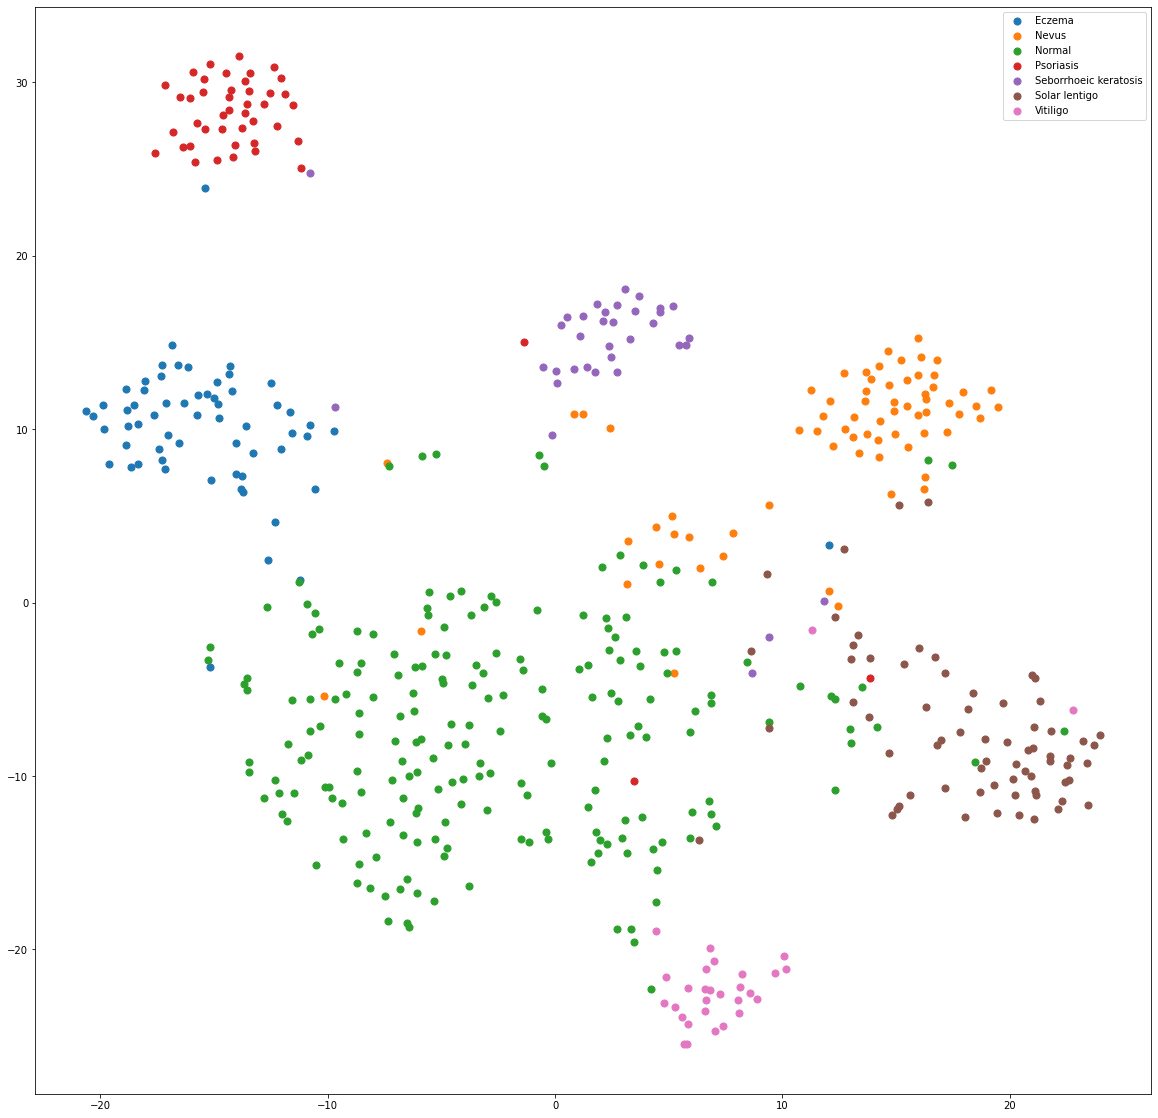

In [49]:
k = 0
prev = 0
ALL_FILE_PATH = "/home/r10941036/Explainable AI Project/DATA/val/"
ALL_FILE_LIST = sorted(os.listdir(ALL_FILE_PATH))
plt.figure(figsize=(20, 20))
for file in ALL_FILE_LIST:
    sub_list = os.listdir(ALL_FILE_PATH+file)
    if(k==0):
        plt.scatter(X_r[:len(sub_list),0],X_r[:len(sub_list),1],s=50,label=file)
        prev += len(sub_list)
    else:
        plt.scatter(X_r[prev:prev+len(sub_list),0],X_r[prev:prev+len(sub_list),1],s=50,label=file)
        prev += len(sub_list)
    k+=1
plt.legend()
#ax.view_init(0, 0)
plt.draw()